In [14]:
import os, gc, sys
from pathlib import Path
import torch
if not torch.cuda.is_available():
    os.environ["XFORMERS_DISABLED"] = "1"  # avoid xformers CUDA/CPU mismatch crashes

import numpy as np
import torch.nn.functional as F
import cv2
import OpenEXR, Imath
import laspy
from PIL import Image
from scipy import ndimage
from scipy.stats import skew
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from segment_anything.utils.transforms import ResizeLongestSide
import matplotlib.pyplot as plt

# Vendored DA3 package path
DA3_SRC = Path.cwd() / "Depth-Anything-3" / "src"
if DA3_SRC.exists() and str(DA3_SRC) not in sys.path:
    sys.path.insert(0, str(DA3_SRC))

# ── Config ──
DATASET = "test2"
MODEL_VARIANT = "da3_giant"   # "da3_giant" or "da3_nested"

DA3_HF_MODELS = {
    "da3_giant":  "depth-anything/DA3-GIANT-1.1",
    "da3_nested": "depth-anything/DA3NESTED-GIANT-LARGE-1.1",
}

INPUT_FOLDER = f"./data/{DATASET}"
OUTPUT_FOLDER = "./pointclouds2"
GT_TO_CENTIMETERS = 10000.0
CAMERA_FOV = 90.0       # known UE camera FOV (used as fallback)
MIN_DEPTH = 0.001       # metres

# ── Sky detection tuning ──
SKY_KNEE_FRAC = 0.01    # GT sky: histogram knee fraction (↑ = lower threshold = more sky)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device.upper()}, Dataset: {DATASET}")
print(f"Model:  {MODEL_VARIANT} → {DA3_HF_MODELS[MODEL_VARIANT]}")
print(f"Sky:    knee_frac={SKY_KNEE_FRAC}")

Device: CUDA, Dataset: test2
Model:  da3_giant → depth-anything/DA3-GIANT-1.1
Sky:    knee_frac=0.01


In [9]:
def load_exr_rgb(path):
    exr = OpenEXR.InputFile(path)
    dw = exr.header()['dataWindow']
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    rgb = np.stack([np.frombuffer(exr.channel(c, FLOAT), np.float32).reshape(h, w) for c in 'RGB'], axis=-1)
    return Image.fromarray(np.clip(rgb * 255, 0, 255).astype(np.uint8))

def load_exr_depth(path):
    exr = OpenEXR.InputFile(path)
    header = exr.header()
    dw = header['dataWindow']
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)
    channels = list(header['channels'].keys())
    for name in ['R', 'SceneDepth', 'Z']:
        if name in channels:
            depth = np.frombuffer(exr.channel(name, FLOAT), np.float32).reshape(h, w).copy()
            break
    return (depth * GT_TO_CENTIMETERS) / 100.0

def load_image(path):
    return load_exr_rgb(path) if path.lower().endswith('.exr') else Image.open(path).convert('RGB')

# ── Find files ──
files = os.listdir(INPUT_FOLDER)
gt_rgb_path = next(os.path.join(INPUT_FOLDER, f) for f in files if f.endswith('.exr') and 'depth' not in f.lower() and 'scenedepth' not in f.lower())
edited_path = next(os.path.join(INPUT_FOLDER, f) for f in files if 'edit' in f.lower() and f.endswith(('.png', '.jpg', '.exr')))
gt_depth_path = next(os.path.join(INPUT_FOLDER, f) for f in files if 'SceneDepth' in f and 'WorldUnits' not in f and f.endswith('.exr'))

print(f"Original: {os.path.basename(gt_rgb_path)}")
print(f"Edited:   {os.path.basename(edited_path)}")
print(f"GT Depth: {os.path.basename(gt_depth_path)}")

Original: HighresScreenshot00000.exr
Edited:   edit2.png
GT Depth: HighresScreenshot00000_SceneDepth.exr


In [10]:
# ── Load all data ──
original_img = load_image(gt_rgb_path)
edited_img = load_image(edited_path)
gt_depth = load_exr_depth(gt_depth_path)
h_gt, w_gt = gt_depth.shape

# ── Detect sky via density knee ──
_gt_pos = gt_depth[gt_depth > MIN_DEPTH].ravel()
_bin_w = 0.25
_bins = np.arange(0, _gt_pos.max() + _bin_w, _bin_w)
_counts, _edges = np.histogram(_gt_pos, bins=_bins)
_centres = (_edges[:-1] + _edges[1:]) / 2

_peak_count = _counts.max()
_peak_bin = _centres[np.argmax(_counts)]
_cands = np.where((_centres > _peak_bin) & (_counts < _peak_count * SKY_KNEE_FRAC))[0]
sky_threshold = _centres[_cands[0]] if len(_cands) > 0 else _gt_pos.max()

sky_mask = gt_depth >= sky_threshold
depth_cap = gt_depth[~sky_mask & (gt_depth > 0)].max() if sky_mask.any() else gt_depth.max()
valid_depth_mask = ~sky_mask & (gt_depth > MIN_DEPTH)

edited_resized = edited_img.resize(original_img.size, Image.BILINEAR) if edited_img.size != original_img.size else edited_img

print(f"Original: {original_img.size}, Edited: {edited_img.size}")
print(f"GT depth: {gt_depth.shape}, range: {gt_depth.min():.6f}m - {gt_depth.max():.2f}m")
print(f"Sky threshold (knee): {sky_threshold:.2f}m, sky pixels: {sky_mask.sum():,} ({sky_mask.mean()*100:.1f}%)")
print(f"Depth cap (max non-sky): {depth_cap:.2f}m")

Original: (1526, 858), Edited: (2752, 1536)
GT depth: (858, 1526), range: 0.007629m - 100.00m
Sky threshold (knee): 4.62m, sky pixels: 35,519 (2.7%)
Depth cap (max non-sky): 4.62m


In [11]:
# ── Change detection (GeSCF: SAM Q/K/V attention features + adaptive threshold) ──
for _v in ('mask_gen', 'sam', 'hook', 'qkv1', 'qkv2', 'f1', 'f2', 'cos_sim',
           'prepare_sam', '_hook_qkv', 'sam_masks', 'captured'):
    globals().pop(_v, None)
gc.collect()
torch.cuda.empty_cache()

weights_dir = "./weights"
os.makedirs(weights_dir, exist_ok=True)
weights_path = os.path.join(weights_dir, "sam_vit_b_01ec64.pth")

if not os.path.exists(weights_path):
    print("Downloading SAM ViT-B weights (~375 MB)...")
    import urllib.request
    urllib.request.urlretrieve("https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth", weights_path)

sam = sam_model_registry["vit_b"](checkpoint=weights_path).to(device).eval()
h_img, w_img = np.array(original_img).shape[:2]

captured = {}
def _hook_qkv(module, input, output):
    captured["qkv"] = output.detach()
hook = sam.image_encoder.blocks[8].attn.qkv.register_forward_hook(_hook_qkv)

img_size = sam.image_encoder.img_size
sam_transform = ResizeLongestSide(img_size)
patch_size = 16
sam_scale = img_size / max(h_img, w_img)
feat_h, feat_w = int(h_img * sam_scale + 0.5) // patch_size, int(w_img * sam_scale + 0.5) // patch_size

def prepare_sam(pil_img):
    t = sam_transform.apply_image(np.array(pil_img))
    return sam.preprocess(torch.as_tensor(t, device=device).permute(2, 0, 1).unsqueeze(0).float())

with torch.no_grad():
    sam.image_encoder(prepare_sam(original_img))
    qkv1 = captured["qkv"]
    sam.image_encoder(prepare_sam(edited_resized))
    qkv2 = captured["qkv"]
hook.remove()

del prepare_sam, _hook_qkv
captured.clear()

with torch.no_grad():
    f1, f2 = qkv1.squeeze(0), qkv2.squeeze(0)
    cos_sim = (F.normalize(f1, dim=-1) * F.normalize(f2, dim=-1)).sum(dim=-1)
    dist_map = (1 - cos_sim).cpu().numpy()[:feat_h, :feat_w]

del qkv1, qkv2, f1, f2, cos_sim
torch.cuda.empty_cache()

dist_map = F.interpolate(torch.tensor(dist_map)[None, None].float(), size=(h_img, w_img), mode='bilinear', align_corners=False).squeeze().numpy()
dist_map = ndimage.gaussian_filter(dist_map, sigma=4)
dist_map = (dist_map - dist_map.min()) / (dist_map.max() - dist_map.min() + 1e-8)

sk = skew(dist_map.ravel())
k = np.clip(sk, 1.0, 3.0)
threshold = dist_map.mean() + k * dist_map.std()
initial_mask = dist_map > threshold

mask_gen = SamAutomaticMaskGenerator(sam, points_per_side=16, pred_iou_thresh=0.80, stability_score_thresh=0.85, min_mask_region_area=200)
sam_masks = mask_gen.generate(np.array(edited_resized))
changed_mask = np.zeros((h_img, w_img), dtype=bool)
for seg in sam_masks:
    m = seg["segmentation"]
    if m.sum() > 0 and np.logical_and(m, initial_mask).sum() / m.sum() > 0.3:
        changed_mask |= m
if changed_mask.sum() == 0:
    changed_mask = initial_mask

del sam, mask_gen, sam_masks, captured
gc.collect()
torch.cuda.empty_cache()

if changed_mask.shape != gt_depth.shape:
    changed_mask = cv2.resize(changed_mask.astype(np.uint8), (w_gt, h_gt), interpolation=cv2.INTER_NEAREST) > 0
unchanged_mask = ~changed_mask

print(f"Changed pixels: {changed_mask.sum():,} ({changed_mask.mean()*100:.1f}%)")
print(f"Threshold: {threshold:.4f} (skew={sk:.2f}, k={k:.2f})")

Changed pixels: 103,173 (7.9%)
Threshold: 0.5628 (skew=2.67, k=2.67)


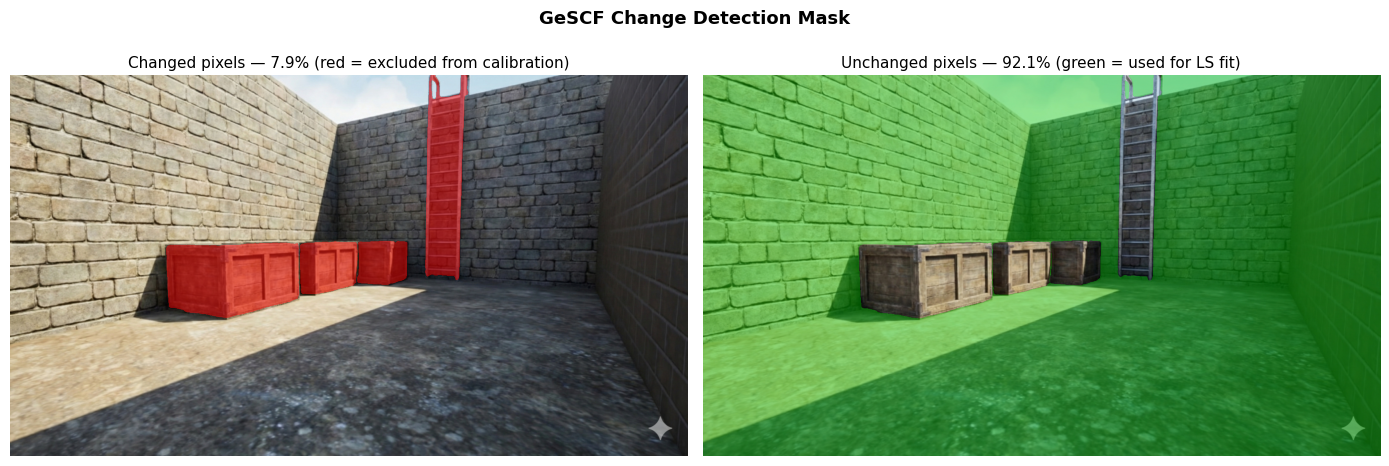

In [12]:
# ── Change mask visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overlay_c = np.zeros((*changed_mask.shape, 4), dtype=np.float32)
overlay_c[changed_mask] = [1, 0, 0, 0.5]

overlay_u = np.zeros((*changed_mask.shape, 4), dtype=np.float32)
overlay_u[unchanged_mask] = [0, 0.8, 0, 0.4]

axes[0].imshow(edited_resized)
axes[0].imshow(overlay_c)
axes[0].set_title(f'Changed pixels — {changed_mask.mean()*100:.1f}% (red = excluded from calibration)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(edited_resized)
axes[1].imshow(overlay_u)
axes[1].set_title(f'Unchanged pixels — {unchanged_mask.mean()*100:.1f}% (green = used for LS fit)', fontsize=11)
axes[1].axis('off')

plt.suptitle('GeSCF Change Detection Mask', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── Run DA3 on edited image ──
for _v in ('da3_model', 'prediction', 'pred_sky'):
    globals().pop(_v, None)
gc.collect()
torch.cuda.empty_cache()

from depth_anything_3.api import DepthAnything3

hf_id = DA3_HF_MODELS[MODEL_VARIANT]
print(f"Loading {MODEL_VARIANT}: {hf_id}")

da3_model = DepthAnything3.from_pretrained(hf_id)
da3_model = da3_model.to(device=device)

with torch.no_grad():
    prediction = da3_model.inference([edited_img])

pred_depth = prediction.depth[0]  # numpy array (H_pred, W_pred)
pred_sky = prediction.sky[0] if prediction.sky is not None else None
print(f"Raw prediction: {pred_depth.shape}, range: {pred_depth.min():.2f}m - {pred_depth.max():.2f}m")
if pred_sky is not None:
    print(f"Raw sky prediction: {pred_sky.shape}, range: {pred_sky.min():.3f} - {pred_sky.max():.3f}")
else:
    print("DA3 sky prediction: None (falling back to depth-cap heuristic)")

# DA3 predicted intrinsics vs known UE FOV
if prediction.intrinsics is not None:
    fx_pred = prediction.intrinsics[0, 0, 0]
    fy_pred = prediction.intrinsics[0, 1, 1]
    h_pred, w_pred = pred_depth.shape
    fov_x_pred = 2 * np.degrees(np.arctan(w_pred / (2 * fx_pred)))
    fov_y_pred = 2 * np.degrees(np.arctan(h_pred / (2 * fy_pred)))
    print(f"DA3 predicted intrinsics: fx={fx_pred:.1f}, fy={fy_pred:.1f}")
    print(f"DA3 predicted FOV: {fov_x_pred:.1f}° x {fov_y_pred:.1f}° (UE ground truth: {CAMERA_FOV}°)")
else:
    print("DA3 intrinsics: None (using known UE FOV for point cloud)")

# Resize to GT resolution
pred_depth = cv2.resize(pred_depth, (w_gt, h_gt), interpolation=cv2.INTER_LINEAR)
print(f"Resized to GT: {pred_depth.shape}")
if pred_sky is not None:
    pred_sky = cv2.resize(pred_sky, (w_gt, h_gt), interpolation=cv2.INTER_LINEAR)
    print(f"Resized sky to GT: {pred_sky.shape}")

del da3_model, prediction
gc.collect()
torch.cuda.empty_cache()
print(f"Cleanup done")

Loading da3_giant: depth-anything/DA3-GIANT-1.1


config.json: 0.00B [00:00, ?B/s]

c:\Users\parve\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\parve\.cache\huggingface\hub\models--depth-anything--DA3-GIANT-1.1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[INFO ] using SwiGLU layer as FFN


ModuleNotFoundError: No module named 'evo'

In [14]:
# ── Least squares scaling on unchanged regions ──
valid_base = unchanged_mask & valid_depth_mask & np.isfinite(pred_depth) & np.isfinite(gt_depth)

pred_cap = np.percentile(pred_depth[valid_base], 98)
valid = valid_base & (pred_depth <= pred_cap)

A = np.vstack([pred_depth[valid].flatten(), np.ones(valid.sum())]).T
scale, shift = np.linalg.lstsq(A, gt_depth[valid].flatten(), rcond=None)[0]
depth_scaled = pred_depth * scale + shift

eval_mask = valid
mae = np.mean(np.abs(depth_scaled[eval_mask] - gt_depth[eval_mask]))
rmse = np.sqrt(np.mean((depth_scaled[eval_mask] - gt_depth[eval_mask]) ** 2))
print(f"Pred cap (p98): {pred_cap:.2f}m — {(valid_base & ~valid).sum():,} outliers excluded")
print(f"LS fit: scale={scale:.4f}, shift={shift:.4f}")
print(f"Unchanged regions — MAE: {mae:.4f}m, RMSE: {rmse:.4f}m")
print(f"Scaled depth range: {depth_scaled.min():.4f}m - {depth_scaled.max():.2f}m")

Pred cap (p98): 1.82m — 23,457 outliers excluded
LS fit: scale=2.2342, shift=0.0706
Unchanged regions — MAE: 0.0206m, RMSE: 0.0776m
Scaled depth range: 0.6745m - 4.40m


GT sky threshold (knee): 4.62m
  Scene (< knee): 1,273,789 pixels (97.3%)
  Tail  (≥ knee): 35,519 pixels (2.7%)
  Percentiles — p90: 3.76m, p95: 4.17m, p98: 30.10m

Scaled da3_giant depth range: 0.67m - 4.40m
  DA3 at GT-sky pixels:     3.02m - 4.29m (mean 3.69m)
  DA3 at GT-non-sky pixels: 0.67m - 4.40m (mean 1.96m)
  → DA3 clamps sky to ~scene max (by design), so sky ≈ far objects in depth


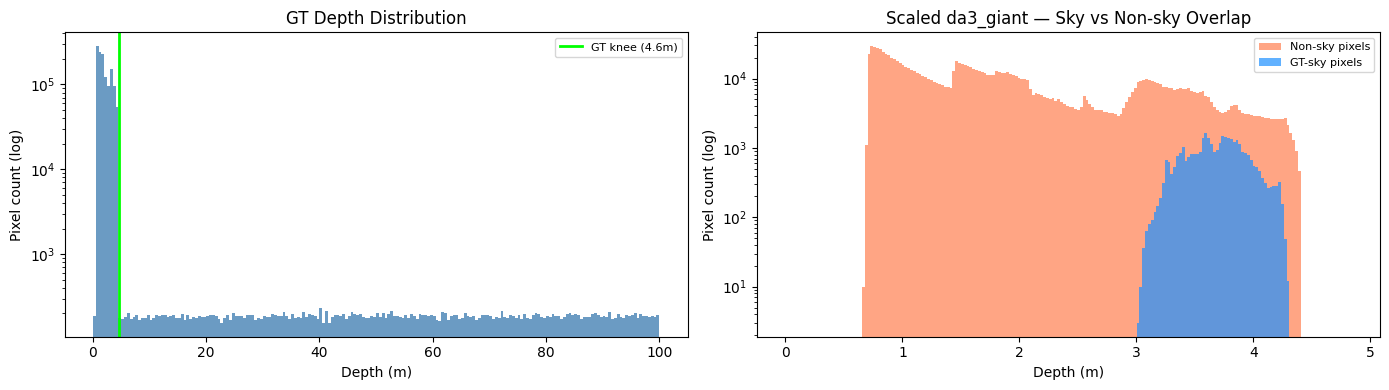

In [15]:
# ── Depth distribution analysis ──
gt_pos = gt_depth[gt_depth > MIN_DEPTH].ravel()

# Percentile check
p90 = np.percentile(gt_pos, 90)
p95 = np.percentile(gt_pos, 95)
p98 = np.percentile(gt_pos, 98)

# Count pixels in each region
n_scene = (gt_pos < sky_threshold).sum()
n_tail = (gt_pos >= sky_threshold).sum()

print(f"GT sky threshold (knee): {sky_threshold:.2f}m")
print(f"  Scene (< knee): {n_scene:,} pixels ({n_scene/len(gt_pos)*100:.1f}%)")
print(f"  Tail  (≥ knee): {n_tail:,} pixels ({n_tail/len(gt_pos)*100:.1f}%)")
print(f"  Percentiles — p90: {p90:.2f}m, p95: {p95:.2f}m, p98: {p98:.2f}m")

# DA3 sky behavior: sky pixels are clamped to quantile(non_sky, 0.99) internally
pred_pos = depth_scaled[depth_scaled > MIN_DEPTH].ravel()
pred_sky_vals = depth_scaled[sky_mask & (depth_scaled > MIN_DEPTH)]
pred_nonsky_vals = depth_scaled[~sky_mask & (depth_scaled > MIN_DEPTH)]
print(f"\nScaled {MODEL_VARIANT} depth range: {pred_pos.min():.2f}m - {pred_pos.max():.2f}m")
if len(pred_sky_vals) > 0:
    print(f"  DA3 at GT-sky pixels:     {pred_sky_vals.min():.2f}m - {pred_sky_vals.max():.2f}m (mean {pred_sky_vals.mean():.2f}m)")
    print(f"  DA3 at GT-non-sky pixels: {pred_nonsky_vals.min():.2f}m - {pred_nonsky_vals.max():.2f}m (mean {pred_nonsky_vals.mean():.2f}m)")
    print(f"  → DA3 clamps sky to ~scene max (by design), so sky ≈ far objects in depth")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# GT depth histogram
axes[0].hist(gt_pos, bins=200, range=(0, min(gt_pos.max(), 110)), color='steelblue', alpha=0.8)
axes[0].axvline(sky_threshold, color='lime', ls='-', lw=2, label=f'GT knee ({sky_threshold:.1f}m)')
axes[0].set_yscale('log')
axes[0].set_xlabel('Depth (m)')
axes[0].set_ylabel('Pixel count (log)')
axes[0].set_title('GT Depth Distribution')
axes[0].legend(fontsize=8)

# Scaled predicted depth — show sky vs non-sky overlap
clip_hi = min(pred_pos.max() * 1.1, 110)
axes[1].hist(pred_nonsky_vals, bins=200, range=(0, clip_hi), color='coral', alpha=0.7, label='Non-sky pixels')
if len(pred_sky_vals) > 0:
    axes[1].hist(pred_sky_vals, bins=200, range=(0, clip_hi), color='dodgerblue', alpha=0.7, label='GT-sky pixels')
axes[1].set_yscale('log')
axes[1].set_xlabel('Depth (m)')
axes[1].set_ylabel('Pixel count (log)')
axes[1].set_title(f'Scaled {MODEL_VARIANT} — Sky vs Non-sky Overlap')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

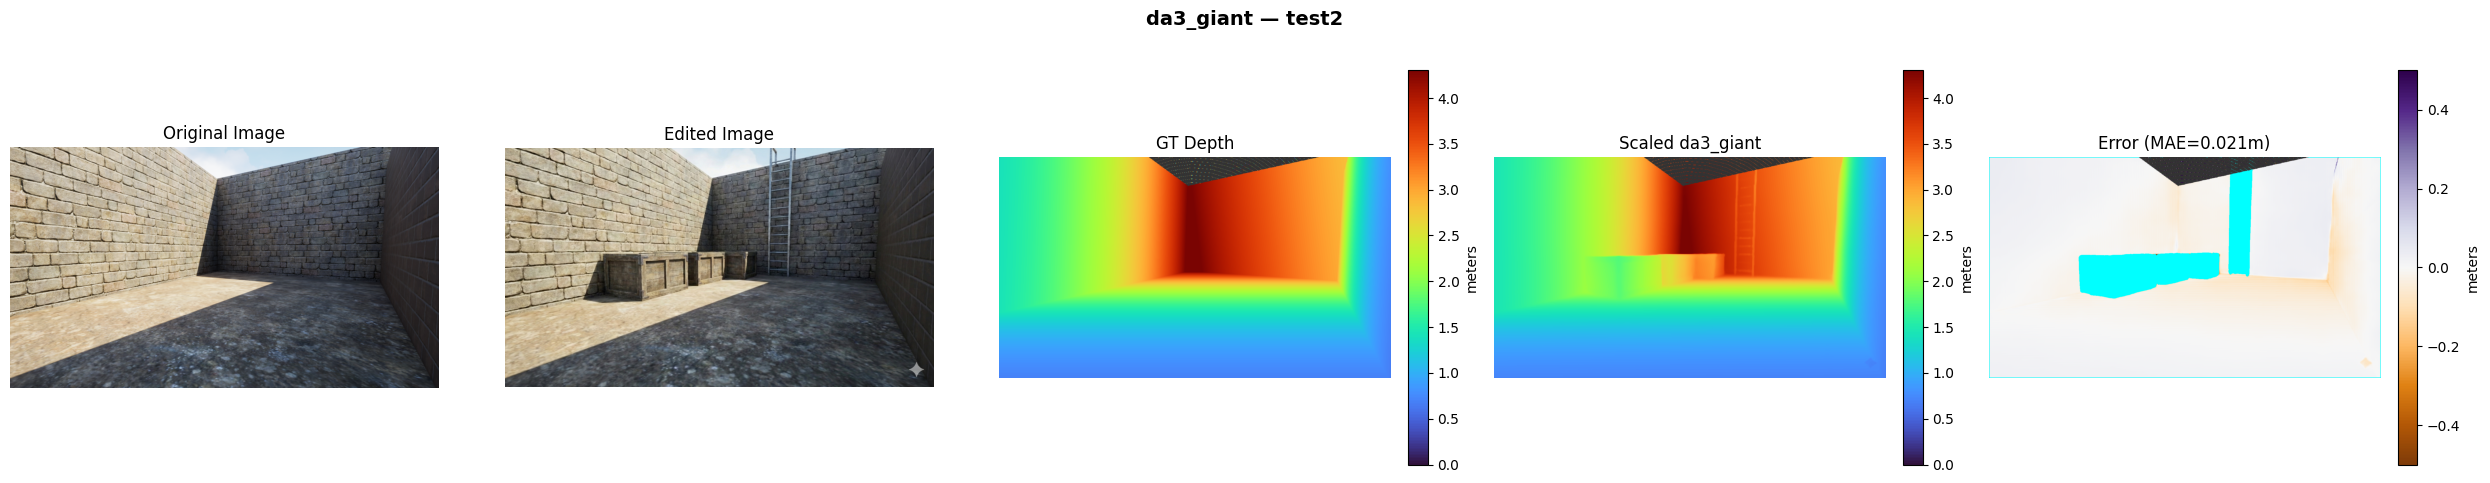

In [16]:
# ── Visualization ──
non_sky_depths = gt_depth[~sky_mask & (gt_depth > MIN_DEPTH)]
vmin_depth = 0
vmax_depth = np.percentile(non_sky_depths, 99)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(original_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(edited_img)
axes[1].set_title('Edited Image')
axes[1].axis('off')

cmap_depth = plt.cm.turbo
norm_depth = plt.Normalize(vmin=vmin_depth, vmax=vmax_depth)
gt_rgba = cmap_depth(norm_depth(np.clip(gt_depth, vmin_depth, vmax_depth)))
gt_rgba[sky_mask] = [0.2, 0.2, 0.2, 1.0]
axes[2].imshow(gt_rgba)
axes[2].set_title('GT Depth')
axes[2].axis('off')
sm_depth = plt.cm.ScalarMappable(cmap=cmap_depth, norm=norm_depth)
sm_depth.set_array([])
plt.colorbar(sm_depth, ax=axes[2], fraction=0.046, pad=0.04, label='meters')

pred_rgba = cmap_depth(norm_depth(np.clip(depth_scaled, vmin_depth, vmax_depth)))
pred_rgba[sky_mask] = [0.2, 0.2, 0.2, 1.0]
axes[3].imshow(pred_rgba)
axes[3].set_title(f'Scaled {MODEL_VARIANT}')
axes[3].axis('off')
plt.colorbar(sm_depth, ax=axes[3], fraction=0.046, pad=0.04, label='meters')

unchanged_mask_clean = ndimage.binary_erosion(unchanged_mask, iterations=2)
error_signed = depth_scaled - gt_depth
error_range = 0.5
cmap_error = plt.cm.PuOr
norm_error = plt.Normalize(vmin=-error_range, vmax=error_range)
error_rgba = cmap_error(norm_error(np.clip(error_signed, -error_range, error_range)))
error_rgba[~unchanged_mask_clean] = [0.0, 1.0, 1.0, 1.0]
error_rgba[sky_mask] = [0.2, 0.2, 0.2, 1.0]

axes[4].imshow(error_rgba)
axes[4].set_title(f'Error (MAE={mae:.3f}m)')
axes[4].axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap_error, norm=norm_error)
sm.set_array([])
plt.colorbar(sm, ax=axes[4], fraction=0.046, pad=0.04, label='meters')

plt.suptitle(f'{MODEL_VARIANT} — {DATASET}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Generate point cloud ──
w_edit, h_edit = edited_img.size
depth_full = cv2.resize(depth_scaled, (w_edit, h_edit), interpolation=cv2.INTER_LINEAR)
DA3_SKY_THRESH = 0.30
pred_sky_full = None if pred_sky is None else cv2.resize(pred_sky, (w_edit, h_edit), interpolation=cv2.INTER_LINEAR)

# Sky filtering:
#   Unchanged pixels → trust GT sky_mask (scene hasn't changed there)
#   Changed pixels   → use DA3's own sky prediction when available
#   Fallback         → use the old depth-cap heuristic only if sky logits are unavailable
sky_gt_full = cv2.resize(sky_mask.astype(np.uint8), (w_edit, h_edit),
                         interpolation=cv2.INTER_NEAREST) > 0
changed_full = cv2.resize(changed_mask.astype(np.uint8), (w_edit, h_edit),
                          interpolation=cv2.INTER_NEAREST) > 0

depth_cap_scaled = depth_cap * scale + shift
sky_unchanged = sky_gt_full & ~changed_full
sky_changed_fallback = changed_full & (depth_full > depth_cap_scaled)

if pred_sky_full is not None:
    sky_changed_model = changed_full & (pred_sky_full >= DA3_SKY_THRESH)
    sky_changed = sky_changed_model
    sky_changed_mode = f"da3 sky >= {DA3_SKY_THRESH:.2f}"
else:
    sky_changed_model = np.zeros_like(changed_full, dtype=bool)
    sky_changed = sky_changed_fallback
    sky_changed_mode = "depth cap fallback"

sky_final = sky_unchanged | sky_changed

focal = w_edit / (2 * np.tan(np.radians(CAMERA_FOV / 2)))
cx, cy = w_edit / 2, h_edit / 2
xx, yy = np.meshgrid(np.arange(w_edit), np.arange(h_edit))

z = depth_full.flatten()
x = (xx.flatten() - cx) * z / focal
y = (yy.flatten() - cy) * z / focal
rgb = np.array(edited_img).reshape(-1, 3)

mask = (z >= MIN_DEPTH) & ~sky_final.flatten()
x, y, z, rgb = x[mask], y[mask], z[mask], rgb[mask]
print(f"Point cloud: {len(z):,} points")
print(f"  Depth cap (scaled):      {depth_cap_scaled:.2f}m")
print(f"  sky_unchanged (GT knee): {sky_unchanged.sum():,} ({sky_unchanged.mean()*100:.1f}%)")
print(f"  sky_changed ({sky_changed_mode}): {sky_changed.sum():,} ({sky_changed.mean()*100:.1f}%)")
print(f"  sky_changed (depth cap fallback): {sky_changed_fallback.sum():,} ({sky_changed_fallback.mean()*100:.1f}%)")
if pred_sky_full is not None and np.any(changed_full):
    changed_scores = pred_sky_full[changed_full]
    print(f"  DA3 sky score in changed pixels: {changed_scores.min():.3f} - {changed_scores.max():.3f} (mean {changed_scores.mean():.3f})")
print(f"  sky_final:               {sky_final.sum():,} ({sky_final.mean()*100:.1f}%)")

In [18]:
# ── Save as LAS ──
output_path = f"{OUTPUT_FOLDER}/{DATASET}_{MODEL_VARIANT}.las"

header = laspy.LasHeader(point_format=3, version="1.2")
header.scales = np.array([0.001, 0.001, 0.001])
las = laspy.LasData(header=header)

las.x = z       # forward
las.y = -x      # right
las.z = -y      # up
las.red = rgb[:, 0].astype(np.uint16) * 256
las.green = rgb[:, 1].astype(np.uint16) * 256
las.blue = rgb[:, 2].astype(np.uint16) * 256

las.write(output_path)
print(f"Saved {len(z):,} points to {output_path}")

Saved 4,130,019 points to ./pointclouds2/test2_da3_giant.las


In [ ]:
# ── Quick inline point cloud preview ──
import plotly.graph_objects as go

MAX_PREVIEW = 200_000
step_pc = max(1, len(z) // MAX_PREVIEW)
xs, ys, zs = x[::step_pc], y[::step_pc], z[::step_pc]
cs = rgb[::step_pc]

# Tight axis ranges from actual data (p1–p99 + small padding)
# so the view starts already fitted to the scene instead of zoomed way out
_pad = 0.2
x_range = [max(0.0, float(zs.min()) - _pad),  float(np.percentile(zs, 99)) + _pad]
y_range = [float(np.percentile(-xs, 1)) - _pad, float(np.percentile(-xs, 99)) + _pad]
z_range = [float(np.percentile(-ys, 1)) - _pad, float(np.percentile(-ys, 99)) + _pad]

fig = go.Figure(data=[go.Scatter3d(
    x=zs, y=-xs, z=-ys, mode='markers',
    marker=dict(
        size=1,
        color=['rgb({},{},{})'.format(r,g,b) for r,g,b in cs],
    )
)])
fig.update_layout(
    scene=dict(
        xaxis_title='Depth', yaxis_title='Right', zaxis_title='Up',
        xaxis=dict(range=x_range),
        yaxis=dict(range=y_range),
        zaxis=dict(range=z_range),
        aspectmode='data',
        camera=dict(eye=dict(x=-1.5, y=-1.0, z=0.5)),
    ),
    margin=dict(l=0, r=0, t=30, b=0),
    height=700,
    title=f'{MODEL_VARIANT} — {len(zs):,} / {len(z):,} pts',
)
fig.show()

In [ ]:
# ── Cleanup ──
if torch.cuda.is_available():
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated")